**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [1]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):            
        images_paths.append(os.path.join(path, filename))
    
    return np.stack(images_paths)

class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, images, masks, transform, aug=None,):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
        self.aug = aug
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):        
        im_name = self.images[idx]
        mask_name = self.masks[idx]
        
        image = cv2.imread(im_name)[:,:,::-1] / 255.0  # ::-1 to convert from BGR to RGB
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        
        if self.aug:
            sample = self.aug(
                image=image,
                mask=mask,
            )
        else:
            sample = {
                'image': image,
                'mask': mask,
            }
        
        sample['image'] = self.transform(sample['image']).float()
        sample['mask'] = self.transform(sample['mask']).float()

        return sample

In [3]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [4]:
train_dataset = RoadDataset(X_train, y_train, transform)

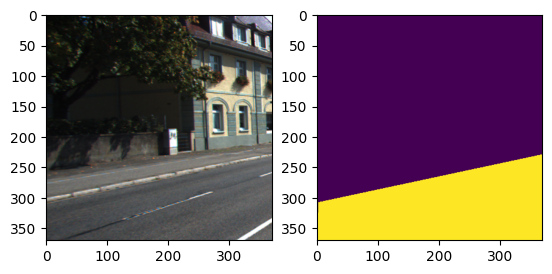

In [5]:
sample = train_dataset[110]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


In [6]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 648


Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

Good luck!

In [7]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

In [8]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[:, :, border_len:current_size-border_len, border_len:current_size-border_len]
    return images

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(128, 64)
        
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv1(x)
        
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)
        
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)
        
        
        return torch.sigmoid(self.outc(x))

In [12]:
from tqdm import tqdm

In [13]:
def train_model(model, train_dataset, test_dataset, criterion, optimizer, num_epochs, model_name):
    train_losses = []
    test_ious = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_dataset, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, masks in progress_bar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            torch.cuda.empty_cache()
            optimizer.zero_grad()
            outputs = model(images)
            # plt.subplot(1, 3, 1)
            # plt.imshow(images[0].permute(1, 2, 0))
            # plt.subplot(1, 3, 2)
            # plt.imshow(masks[0].permute(1, 2, 0))
            # plt.subplot(1, 3, 3)
            # plt.imshow(outputs[0].detach().cpu().permute(1, 2, 0))
            outputs_cropped = central_crop(outputs, 388)
            masks_cropped = central_crop(masks, 388)
            
            loss = criterion(outputs_cropped, masks_cropped)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        avg_loss = running_loss / len(train_dataset)
        train_losses.append(avg_loss)
        
        model.eval()
        all_preds = []
        all_masks = []
        
        with torch.no_grad():
            for images, masks in test_dataset:
                images = images.to(device)
                masks = masks.to(device)
                
                outputs = model(images)
                outputs_cropped = central_crop(outputs, 388)
                masks_cropped = central_crop(masks, 388)
                
                preds = (outputs_cropped > 0.5).float().cpu().numpy()
                all_preds.extend(preds)
                all_masks.extend(masks_cropped.cpu().numpy())
        
        iou = calc_iou(all_preds, all_masks)
        test_ious.append(iou)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, IoU: {iou:.4f}')
    
    return train_losses, test_ious

In [14]:
import albumentations as A

def get_train_augmentations():
    return A.Compose([
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=0, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.Affine(
            translate_percent=(-0.1, 0.1),
            scale=(0.9, 1.1),
            rotate=(-15, 15),
            p=0.5
        ),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.GridDistortion(p=0.3),
        ], p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.GaussNoise(p=0.2),
        A.GaussianBlur(blur_limit=3, p=0.2),
    ])

def get_test_augmentations():
    return A.Compose([
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=0, p=1.0),
    ])

In [15]:
class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, images, masks, transform, aug=None, cache_in_ram=True):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
        self.aug = aug
        self.cache_in_ram = cache_in_ram
        
        if cache_in_ram:
            self.cached_images = []
            self.cached_masks = []
            print("Caching data in RAM...")
            for img_path, mask_path in tqdm(zip(self.images, self.masks), total=len(self.images)):
                image = cv2.imread(img_path)[:,:,::-1]
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                self.cached_images.append(image)
                self.cached_masks.append(mask)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        if self.cache_in_ram:
            image = self.cached_images[idx].copy()
            mask = self.cached_masks[idx].copy()
        else:
            im_name = self.images[idx]
            mask_name = self.masks[idx]
            
            image = cv2.imread(im_name)[:,:,::-1]
            mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        
        if self.aug:
            augmented = self.aug(
                image=image,
                mask=mask,
            )
            image = augmented['image']
            mask = augmented['mask']
        
        image = image.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)
        
        image = self.transform(image).float()
        mask = self.transform(mask).float()

        return  image, mask

In [16]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = RoadDataset(X_train, y_train, transform, get_train_augmentations())

Caching data in RAM...


  0%|          | 0/648 [00:00<?, ?it/s]

100%|██████████| 648/648 [00:01<00:00, 334.60it/s]


In [17]:
def show_sample(dataset, sample_index=110):
    image, mask = dataset[sample_index]
    plt.subplot(1, 2, 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.subplot(1, 2, 2)
    plt.imshow(mask.permute(1, 2, 0))

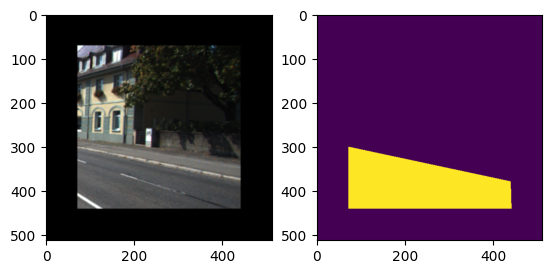

In [18]:
show_sample(train_dataset)

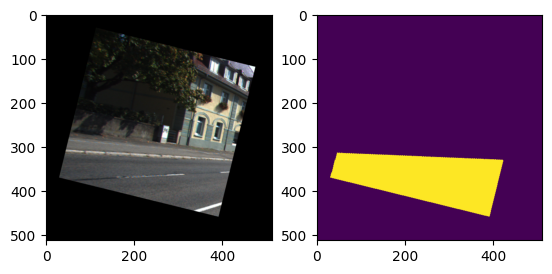

In [19]:
show_sample(train_dataset)

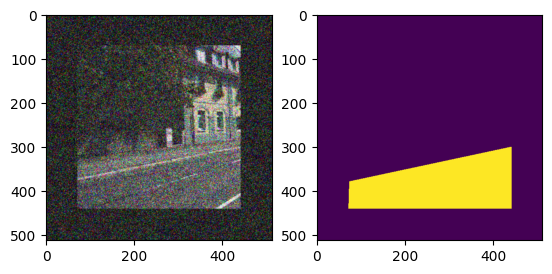

In [20]:
show_sample(train_dataset)

In [21]:
X_test = get_paths("data/test/images")
y_test = get_paths("data/test/gt")

test_dataset = RoadDataset(X_test, y_test, transform, get_test_augmentations())

Caching data in RAM...


100%|██████████| 219/219 [00:00<00:00, 338.99it/s]


In [22]:
len(test_dataset)

219

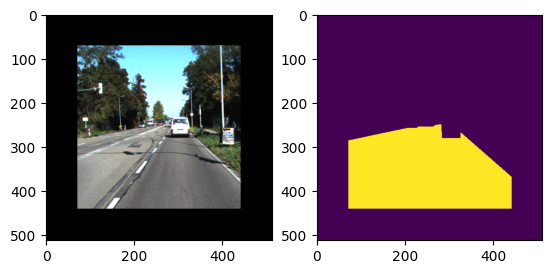

In [23]:
show_sample(test_dataset)

In [24]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        predictions = predictions.float().reshape(-1)
        targets = targets.float().reshape(-1)
        
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)
        return 1 - dice

In [25]:
from torch.utils.data import DataLoader
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [26]:
# unet_model = UNet().to(device)
# unet_criterion = DiceLoss()
# unet_optimizer = optim.Adam(unet_model.parameters(), lr=1e-4, weight_decay=1e-5)
# unet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(unet_optimizer, mode='max', patience=5, factor=0.5)

# unet_train_losses, unet_val_ious = train_model(
#     unet_model, train_loader, test_loader, unet_criterion, 
#     unet_optimizer, num_epochs=15, model_name='unet'
# )

Time to some optimization

In [27]:
class LightUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        
        self.inc = DoubleConv(n_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(64, 32)
        
        self.outc = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv1(x)
        
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)
        
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)
        
        return torch.sigmoid(self.outc(x))

In [28]:
def train_model_bf16(model, train_dataset, test_dataset, criterion, optimizer, num_epochs, model_name):
    train_losses = []
    test_ious = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_dataset, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, masks in progress_bar:
            images = images.to(device, non_blocking=True, dtype=torch.bfloat16)
            masks = masks.to(device, non_blocking=True)
            torch.cuda.empty_cache()
            optimizer.zero_grad()
            with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                outputs_cropped = central_crop(outputs, 388)
                masks_cropped = central_crop(masks, 388)
                
                loss = criterion(outputs_cropped.float(), masks_cropped)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        avg_loss = running_loss / len(train_dataset)
        train_losses.append(avg_loss)
        
        model.eval()
        all_preds = []
        all_masks = []
        
        with torch.no_grad():
            for images, masks in test_dataset:
                images = images.to(device, non_blocking=True, dtype=torch.bfloat16)
                masks = masks.to(device, non_blocking=True)
                
                with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
                    outputs = model(images)
                    outputs_cropped = central_crop(outputs, 388)
                    masks_cropped = central_crop(masks, 388)
                
                preds = (outputs_cropped > 0.5).float().cpu().numpy()
                all_preds.extend(preds)
                all_masks.extend(masks_cropped.cpu().numpy())
        
        iou = calc_iou(all_preds, all_masks)
        test_ious.append(iou)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, IoU: {iou:.4f}')
    
    return train_losses, test_ious

In [29]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [30]:
unet_model = LightUNet().to(device, dtype=torch.bfloat16)
unet_criterion = DiceLoss()
unet_optimizer = optim.Adam(unet_model.parameters(), lr=1e-4, weight_decay=1e-5)

unet_train_losses, unet_val_ious = train_model_bf16(
    unet_model, train_loader, test_loader, unet_criterion, 
    unet_optimizer, num_epochs=40, model_name='unet'
)

Epoch 1/40: 100%|██████████| 41/41 [01:06<00:00,  1.62s/it, Loss=0.4667]


Epoch 1/40, Loss: 0.6457, IoU: 0.4131


Epoch 2/40: 100%|██████████| 41/41 [01:08<00:00,  1.67s/it, Loss=0.4605]


Epoch 2/40, Loss: 0.5194, IoU: 0.5956


Epoch 3/40: 100%|██████████| 41/41 [01:01<00:00,  1.49s/it, Loss=0.2831]


...

Epoch 38/40, Loss: 0.3531, IoU: 0.6955


Epoch 39/40: 100%|██████████| 41/41 [00:56<00:00,  1.38s/it, Loss=0.4207]


Epoch 39/40, Loss: 0.3511, IoU: 0.7043


Epoch 40/40: 100%|██████████| 41/41 [01:08<00:00,  1.66s/it, Loss=0.4036]


Epoch 40/40, Loss: 0.3617, IoU: 0.6788


In [31]:
unet_train_losses2, unet_val_ious2 = train_model_bf16(
    unet_model, train_loader, test_loader, unet_criterion, 
    unet_optimizer, num_epochs=40, model_name='unet'
)

Epoch 1/40: 100%|██████████| 41/41 [01:26<00:00,  2.11s/it, Loss=0.3485]


Epoch 1/40, Loss: 0.3562, IoU: 0.7019


Epoch 2/40: 100%|██████████| 41/41 [01:12<00:00,  1.76s/it, Loss=0.2616]


Epoch 2/40, Loss: 0.3550, IoU: 0.7215


Epoch 3/40: 100%|██████████| 41/41 [01:07<00:00,  1.64s/it, Loss=0.4381]


...

Epoch 38/40, Loss: 0.3352, IoU: 0.7385


Epoch 39/40: 100%|██████████| 41/41 [01:14<00:00,  1.82s/it, Loss=0.2401]


Epoch 39/40, Loss: 0.3294, IoU: 0.7431


Epoch 40/40: 100%|██████████| 41/41 [01:01<00:00,  1.50s/it, Loss=0.3555]


Epoch 40/40, Loss: 0.3367, IoU: 0.7173


In [32]:
unet_train_losses2, unet_val_ious2 = train_model_bf16(
    unet_model, train_loader, test_loader, unet_criterion, 
    unet_optimizer, num_epochs=20, model_name='unet'
)

Epoch 1/20: 100%|██████████| 41/41 [01:02<00:00,  1.53s/it, Loss=0.2724]


Epoch 1/20, Loss: 0.3345, IoU: 0.7497


Epoch 2/20: 100%|██████████| 41/41 [01:02<00:00,  1.54s/it, Loss=0.2247]


Epoch 2/20, Loss: 0.3338, IoU: 0.7537


Epoch 3/20: 100%|██████████| 41/41 [01:02<00:00,  1.51s/it, Loss=0.2350]


...

Epoch 18/20, Loss: 0.3383, IoU: 0.7509


Epoch 19/20: 100%|██████████| 41/41 [01:02<00:00,  1.52s/it, Loss=0.3355]


Epoch 19/20, Loss: 0.3249, IoU: 0.7583


Epoch 20/20: 100%|██████████| 41/41 [00:35<00:00,  1.15it/s, Loss=0.3296]


Epoch 20/20, Loss: 0.3325, IoU: 0.7606


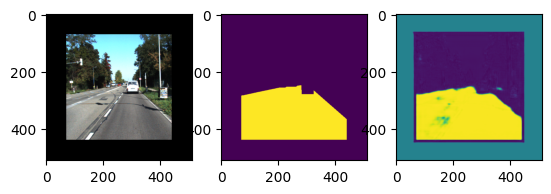

In [37]:
image, mask = test_dataset[110]
image_model = image.unsqueeze(0).to(device, non_blocking=True, dtype=torch.bfloat16)

with torch.no_grad():
    with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
        outputs = unet_model(image_model).detach().cpu().squeeze(0).float()
plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 3, 2)
plt.imshow(mask.permute(1, 2, 0))
plt.subplot(1, 3, 3)
plt.imshow(outputs.permute(1, 2, 0))

In [38]:
del unet_optimizer
del unet_model
torch.cuda.empty_cache()

# Resnet

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.block(x)

class LightResNetSegmentation(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        
        resnet = resnet18(weights=None)
        
        self.encoder1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.encoder2 = nn.Sequential(resnet.maxpool, resnet.layer1)
        self.encoder3 = resnet.layer2
        self.encoder4 = resnet.layer3
        self.encoder5 = resnet.layer4
        
        self.up1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.decoder1 = DecoderBlock(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.decoder2 = DecoderBlock(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.decoder3 = DecoderBlock(128, 64)
        
        self.up4 = nn.ConvTranspose2d(64, 64, 2, 2)
        self.decoder4 = DecoderBlock(128, 64)

        self.up5 = nn.ConvTranspose2d(64, 32, 2, 2)  
        self.decoder5 = DecoderBlock(32, 32)

        self.final_conv = nn.Conv2d(32, num_classes, 1)
        
    def _adaptive_concat(self, decoder_tensor, encoder_tensor):
        """Adaptively concatenate tensors of different spatial sizes"""
        if decoder_tensor.size() != encoder_tensor.size():
            encoder_tensor = torch.nn.functional.interpolate(
                encoder_tensor, 
                size=decoder_tensor.shape[2:], 
                mode='bilinear', 
                align_corners=False
            )
        return torch.cat([decoder_tensor, encoder_tensor], dim=1)
        
    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
        e5 = self.encoder5(e4)
        
        d1 = self.up1(e5)
        d1 = self._adaptive_concat(d1, e4)
        d1 = self.decoder1(d1)
        
        d2 = self.up2(d1)
        d2 = self._adaptive_concat(d2, e3)
        d2 = self.decoder2(d2)
        
        d3 = self.up3(d2)
        d3 = self._adaptive_concat(d3, e2)
        d3 = self.decoder3(d3)
        
        d4 = self.up4(d3)
        d4 = self._adaptive_concat(d4, e1)
        d4 = self.decoder4(d4)

        d5 = self.up5(d4)
        d5 = self.decoder5(d5)
        
        out = self.final_conv(d5)
        return torch.sigmoid(out)


In [73]:
prev_epoch=0

def train_model_bf16(model, train_dataset, test_dataset, criterion, optimizer, num_epochs, model_name):
    global prev_epoch
    train_losses = []
    test_ious = []
    
    for epoch in range(prev_epoch, prev_epoch+num_epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_dataset, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, masks in progress_bar:
            images = images.to(device, non_blocking=True, dtype=torch.bfloat16)
            masks = masks.to(device, non_blocking=True)
            torch.cuda.empty_cache()
            optimizer.zero_grad()
            with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                outputs_cropped = central_crop(outputs, 388)
                masks_cropped = central_crop(masks, 388)              
                loss = criterion(outputs_cropped.float(), masks_cropped)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        avg_loss = running_loss / len(train_dataset)
        train_losses.append(avg_loss)
        
        model.eval()
        all_preds = []
        all_masks = []
        
        with torch.no_grad():
            for images, masks in test_dataset:
                images = images.to(device, non_blocking=True, dtype=torch.bfloat16)
                masks = masks.to(device, non_blocking=True)
                
                with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
                    outputs = model(images)
                    outputs_cropped = central_crop(outputs, 388)
                    masks_cropped = central_crop(masks, 388)
                
                preds = (outputs_cropped > 0.5).float().cpu().numpy()
                all_preds.extend(preds)
                all_masks.extend(masks_cropped.cpu().numpy())
        
        iou = calc_iou(all_preds, all_masks)
        test_ious.append(iou)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, IoU: {iou:.4f}')

    prev_epoch += num_epochs
    return train_losses, test_ious

In [63]:
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [64]:
resnet_model = LightResNetSegmentation().to(device, dtype=torch.bfloat16)
state_dict = torch.load('resnet18-f37072fd.pth') # problems with downloading from site
resnet_model.load_state_dict(state_dict, strict=False)
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4, weight_decay=1e-5)

resnet_train_losses, resnet_val_ious = train_model_bf16(
    resnet_model, train_loader, test_loader, DiceLoss(), 
    resnet_optimizer, num_epochs=40, model_name='resnet'
)

Epoch 1/40:   2%|▏         | 4/162 [01:43<1:08:15, 25.92s/it, Loss=0.6229]


KeyboardInterrupt: 

In [67]:
del resnet_optimizer
del resnet_model
torch.cuda.empty_cache()

In [70]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetSegmentation(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        
        efficientnet = efficientnet_b0(weights=None).features
        
        self.encoder1 = efficientnet[0:2]   # 16
        self.encoder2 = efficientnet[2:3]   # 24
        self.encoder3 = efficientnet[3:4]   # 40
        self.encoder4 = efficientnet[4:6]   # 112
        self.encoder5 = efficientnet[6:8]   # 320
        
        self.up1 = nn.ConvTranspose2d(320, 112, 2, 2)
        self.decoder1 = DecoderBlock(112 + 112, 64)
        
        self.up2 = nn.ConvTranspose2d(64, 40, 2, 2)
        self.decoder2 = DecoderBlock(40 + 40, 32)
        
        self.up3 = nn.ConvTranspose2d(32, 24, 2, 2)
        self.decoder3 = DecoderBlock(24 + 24, 16)
        
        self.up4 = nn.ConvTranspose2d(16, 16, 2, 2)
        self.decoder4 = DecoderBlock(16 + 16, 16)
        
        self.up5 = nn.ConvTranspose2d(16, 16, 2, 2) 
        self.decoder5 = DecoderBlock(16, 16)

        self.final_conv = nn.Conv2d(16, num_classes, 1)
        
    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
        e5 = self.encoder5(e4)
        
        d1 = self.up1(e5)
        d1 = torch.cat([d1, e4], dim=1)
        d1 = self.decoder1(d1)
        
        d2 = self.up2(d1)
        d2 = torch.cat([d2, e3], dim=1)
        d2 = self.decoder2(d2)
        
        d3 = self.up3(d2)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.decoder3(d3)
        
        d4 = self.up4(d3)
        d4 = torch.cat([d4, e1], dim=1)
        d4 = self.decoder4(d4)

        d5 = self.up5(d4)
        d5 = self.decoder5(d5)
        
        out = self.final_conv(d5)
        return torch.sigmoid(out)

In [88]:
import gc
def full_cuda_cleanup():
    """Comprehensive CUDA memory cleanup"""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    
    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()

    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        print(f"After cleanup - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB")

full_cuda_cleanup()

After cleanup - Allocated: 0.10 GB, Cached: 0.18 GB


In [89]:
BATCH_SIZE = 12
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [ ]:
effnet_model = EfficientNetSegmentation().to(device, dtype=torch.bfloat16)
state_dict = torch.load('efficientnet_b0_rwightman-7f5810bc.pth') # problems with downloading from site
effnet_model.load_state_dict(state_dict, strict=False)
effnet_optimizer = optim.Adam(effnet_model.parameters(), lr=1e-4, weight_decay=1e-5)

effnet_train_losses, effnet_test_ious = train_model_bf16(
    effnet_model, train_loader, test_loader, DiceLoss(), 
    effnet_optimizer, num_epochs=140, model_name='resnet'
)

Epoch 1/140: 100%|██████████| 54/54 [00:18<00:00,  2.91it/s, Loss=0.7138]


Epoch 1/140, Loss: 0.7195, IoU: 0.2239


Epoch 2/140: 100%|██████████| 54/54 [00:17<00:00,  3.06it/s, Loss=0.6572]


Epoch 2/140, Loss: 0.6816, IoU: 0.3315


Epoch 3/140: 100%|██████████| 54/54 [00:18<00:00,  2.88it/s, Loss=0.6871]


...

Epoch 119/140: 100%|██████████| 54/54 [00:18<00:00,  2.95it/s, Loss=0.5823]


Epoch 119/140, Loss: 0.4822, IoU: 0.6463


Epoch 120/140: 100%|██████████| 54/54 [00:18<00:00,  2.93it/s, Loss=0.4630]


Epoch 120/140, Loss: 0.4831, IoU: 0.6736


Epoch 121/140:  67%|██████▋   | 36/54 [00:12<00:05,  3.11it/s, Loss=0.5009]

In [ ]:
effnet_train_losses2, effnet_test_ious2 = train_model_bf16(
    effnet_model, train_loader, test_loader, DiceLoss(), 
    effnet_optimizer, num_epochs=140, model_name='resnet'
)